In [19]:
ls

Activator_autoscaler_scheduler_kourier/  power_burst.pdf
all_data_decomposed_10ms_apiserver.csv   power_burst.png
antela_data2.csv                         power_stats.json
antela_data.csv                          scheduler_times.csv
invocation_decomposed10.csv              script_activator.py
invocation_decomposed1.csv               script_autoscale.py
invocation_decomposed2.csv               script_kourier.py
invocation_decomposed3.csv               script_scheduler.py
invocation_decomposed4.csv               Untitled4.ipynb
invocation_decomposed5.csv               Untitled.ipynb
invocation_decomposed6.csv               workload_100ms.csv
invocation_decomposed7.csv               workload_10ms.csv
invocation_decomposed8.csv               workload_10s.csv
invocation_decomposed9.csv               workload_1s.csv
kourier.csv                              workload_200ms.csv
logs/                                    workload_50ms.csv
power_10ms_apiserver.csv


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
files = [
    "invocation_decomposed1.csv",
    "invocation_decomposed2.csv",
    "invocation_decomposed3.csv",
    "invocation_decomposed4.csv",
    "invocation_decomposed5.csv",
    "invocation_decomposed6.csv",
    "invocation_decomposed7.csv",
    "invocation_decomposed8.csv",
    "invocation_decomposed9.csv",
    "invocation_decomposed10.csv"
]


#invocation
dfs = [pd.read_csv(f) for f in files]
all_data = pd.concat(dfs, ignore_index=True)

power = [
     "antela_data.csv",
     "antela_data2.csv"
]

dfs = [pd.read_csv(f) for f in power]
power_df = pd.concat(dfs, ignore_index=True)


In [22]:
all_data.to_csv("all_data_decomposed_10ms_apiserver.csv", index=False)
power_df.to_csv("power_10ms_apiserver.csv", index=False)


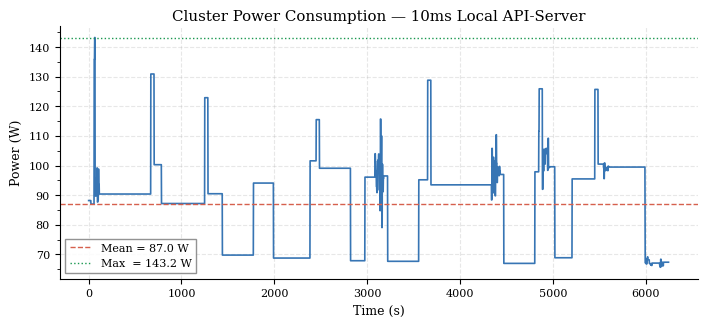

Mean = 87.03 W  |  Max = 143.20 W
Stats sauvegardées : power_stats.json


In [23]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         9,
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()

# ── Chargement et combinaison ─────────────────────────────────────────────────
df1 = pd.read_csv(os.path.join(BASE, "antela_data.csv"))
df2 = pd.read_csv(os.path.join(BASE, "antela_data2.csv"))
df  = pd.concat([df1, df2], ignore_index=True)

df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.sort_values("datetime").reset_index(drop=True)
df["t_s"] = (df["datetime"] - df["datetime"].iloc[0]).dt.total_seconds()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.0, 3.2))

ax.plot(df["t_s"], df["Power_W"], color="#2166ac", lw=1.2, alpha=0.9)

mean_w = df["Power_W"].mean()
ax.axhline(mean_w, color="#d6604d", lw=1.0, linestyle="--",
           label=f"Mean = {mean_w:.1f} W")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (W)")
ax.set_title("Cluster Power Consumption — 10ms Local API-Server", pad=4)
ax.yaxis.set_minor_locator(MultipleLocator(5))

max_w = df["Power_W"].max()
ax.axhline(max_w, color="#1a9850", lw=1.0, linestyle=":",
           label=f"Max  = {max_w:.1f} W")
ax.legend(framealpha=0.85, edgecolor="gray", fancybox=False)

fig.tight_layout(pad=0.5)

fig.savefig(os.path.join(BASE, "power_burst.pdf"), format="pdf", bbox_inches="tight")
fig.savefig(os.path.join(BASE, "power_burst.png"), format="png", dpi=300, bbox_inches="tight")
plt.show()

# ── Mémorisation mean et max ──────────────────────────────────────────────────
import json
stats = {"mean_W": round(mean_w, 2), "max_W": round(max_w, 2)}
with open(os.path.join(BASE, "power_stats.json"), "w") as f:
    json.dump(stats, f, indent=2)
print(f"Mean = {mean_w:.2f} W  |  Max = {max_w:.2f} W")
print("Stats sauvegardées : power_stats.json")

In [24]:
df.to_csv("power_10ms_apiserver.csv", index=False)
